In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_import = pd.read_csv('USImport.csv', delimiter=';')
df_import.head()

,Date,Import Country (Source),Exporter,Importer,HS Code,Country of Origin,Country of Destination,Quantity,Qty Unit,Weight,Wgt Unit,Value (US$),Transport Mode,Products
0,2025-02-28 00:00:00,USA,SUMEC MACHINERY ELECTRIC CO LTD,FIRMAN POWER EQUIPMENT INCORPORATED,851390,CHINA,UNITED STATES,192,PKG,19680,KG,"515637,13",MARITIME,GENERATOR
1,2025-02-28 00:00:00,USA,GUANGZHOU HUIKANG ELECTRONIC TECHNO LOGY CO LTD,CHAI VISION IMPORT LLC,851390,CHINA,UNITED STATES,215,CTN,2506,KG,"65659,89",MARITIME,SAUNA
2,2025-02-27 00:00:00,USA,XUZHOU HEALTHLAND SAUNA EQUIPMENT C WEST OF XUPEI,CHAI VISION IMPORT NJ INC,851390,CHINA,UNITED STATES,57,CTN,3724,KG,"97572,8",MARITIME,SAUNA
3,2025-02-26 00:00:00,USA,ZHEJIANG CAFTP SERVICE CO LTD,AYESPRO LLC,851390,CHINA,UNITED STATES,1049,CTN,9110,KG,"238691,78",MARITIME,LIGHTS
4,2025-02-26 00:00:00,USA,ZHEJIANG TIANZHIXIN SPORTS EQUIPMEN T CO LTD,CHAI VISION IMPORT LLC,851390,CHINA,UNITED STATES,400,CTN,3200,KG,"83843,44",MARITIME,SAUNA


In [4]:
df_import.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6185 entries, 0 to 6184
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Date                     6185 non-null   object
 1   Import Country (Source)  6185 non-null   object
 2   Exporter                 3658 non-null   object
 3   Importer                 6185 non-null   object
 4   HS Code                  6185 non-null   int64 
 5   Country of Origin        6185 non-null   object
 6   Country of Destination   6185 non-null   object
 7   Quantity                 6185 non-null   object
 8   Qty Unit                 6185 non-null   object
 9   Weight                   6185 non-null   object
 10  Wgt Unit                 6185 non-null   object
 11  Value (US$)              6185 non-null   object
 12  Transport Mode           6185 non-null   object
 13  Products                 6185 non-null   object
dtypes: int64(1), object(13)
memory usage: 67

In [5]:
# tính tổng null cho mỗi cột
null_counts = df_import.isnull().sum()
print(null_counts)

Date                          0
Import Country (Source)       0
Exporter                   2527
Importer                      0
HS Code                       0
Country of Origin             0
Country of Destination        0
Quantity                      0
Qty Unit                      0
Weight                        0
Wgt Unit                      0
Value (US$)                   0
Transport Mode                0
Products                      0
dtype: int64


In [ ]:
# Biến đổi dấu , thành . trong cột Value để chuyển đổi sang kiểu số thập phân
df_import['Value (US$)'] = df_import['Value (US$)'].str.replace(',', '.').astype(float)
df_import.info()

In [9]:
df_import['Quantity'] = df_import['Quantity'].str.replace(',', '.').astype(float)
df_import.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6185 entries, 0 to 6184
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     6185 non-null   object 
 1   Import Country (Source)  6185 non-null   object 
 2   Exporter                 3658 non-null   object 
 3   Importer                 6185 non-null   object 
 4   HS Code                  6185 non-null   int64  
 5   Country of Origin        6185 non-null   object 
 6   Country of Destination   6185 non-null   object 
 7   Quantity                 6185 non-null   float64
 8   Qty Unit                 6185 non-null   object 
 9   Weight                   6185 non-null   object 
 10  Wgt Unit                 6185 non-null   object 
 11  Value (US$)              6185 non-null   float64
 12  Transport Mode           6185 non-null   object 
 13  Products                 6185 non-null   object 
dtypes: float64(2), int64(1),

In [11]:
df_import['Weight'] = df_import['Weight'].str.replace(',', '.').astype(float)
df_import.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6185 entries, 0 to 6184
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     6185 non-null   object 
 1   Import Country (Source)  6185 non-null   object 
 2   Exporter                 3658 non-null   object 
 3   Importer                 6185 non-null   object 
 4   HS Code                  6185 non-null   int64  
 5   Country of Origin        6185 non-null   object 
 6   Country of Destination   6185 non-null   object 
 7   Quantity                 6185 non-null   float64
 8   Qty Unit                 6185 non-null   object 
 9   Weight                   6185 non-null   float64
 10  Wgt Unit                 6185 non-null   object 
 11  Value (US$)              6185 non-null   float64
 12  Transport Mode           6185 non-null   object 
 13  Products                 6185 non-null   object 
dtypes: float64(3), int64(1),

In [ ]:
df_import['HS Code'] = df_import['HS Code'].astype(str)
df_import.info()

In [14]:
df_import.describe()

,Quantity,Weight,Value (US$)
count,6185.000000,6185.000000,6.185000e+03
mean,635.528912,14102.567683,1.755716e+05
std,1204.656437,26173.165892,4.960320e+05
min,1.000000,1.000000,0.000000e+00
25%,16.000000,2771.000000,0.000000e+00
50%,44.000000,8000.000000,0.000000e+00
75%,759.000000,10824.000000,1.082104e+05
max,9296.000000,255559.000000,4.450822e+06


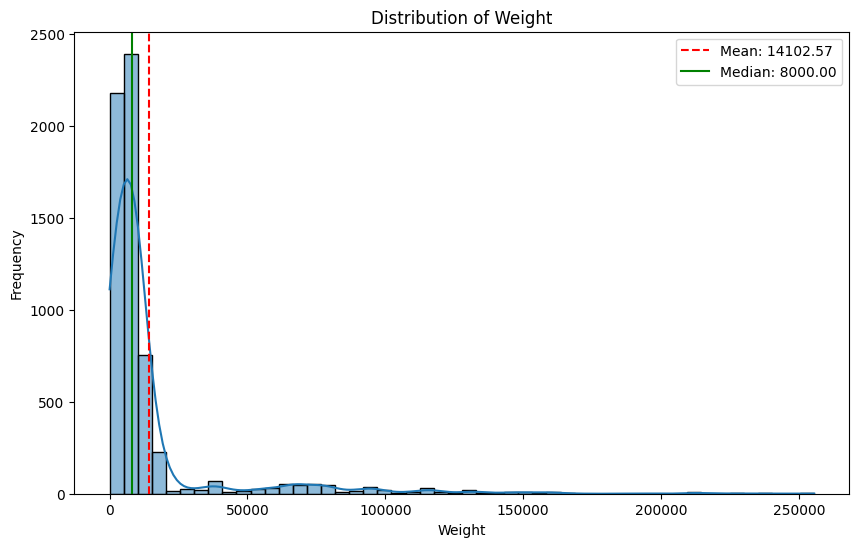

In [17]:
mean_weight = df_import['Weight'].mean()
median_weight = df_import['Weight'].median()
plt.figure(figsize=(10, 6))
sns.histplot(df_import['Weight'], bins=50, kde=True)
plt.title('Distribution of Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.axvline(mean_weight, color='r', linestyle='--', label=f'Mean: {mean_weight:.2f}')
plt.axvline(median_weight, color='g', linestyle='-', label=f'Median: {median_weight:.2f}')
plt.legend()
plt.show()

In [20]:
print(f'Mean Weight: {mean_weight:.2f} KG')
print(f'Median Weight: {median_weight:.0f} KG')
print(f'Mode Weight: {df_import["Weight"].mode()[0]:.0f} KG')
print(f'STD Weight: {df_import["Weight"].std():.2f} KG')
print(f'CV Weight: {df_import["Weight"].std() / mean_weight:.2f}%')

Mean Weight: 14102.57 KG
Median Weight: 8000 KG
Mode Weight: 8800 KG
STD Weight: 26173.17 KG
CV Weight: 1.86%


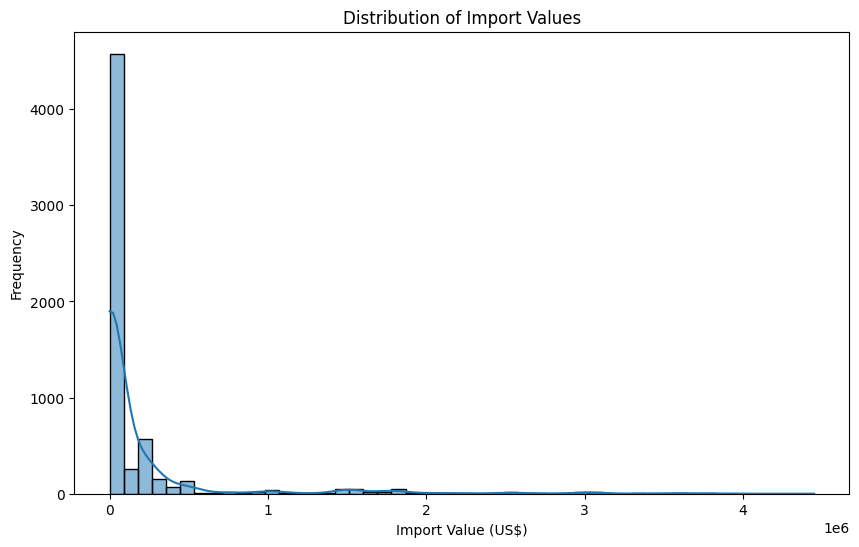

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(df_import['Value (US$)'], bins=50, kde=True)
plt.title('Distribution of Import Values')
plt.xlabel('Import Value (US$)')
plt.ylabel('Frequency')
plt.show()

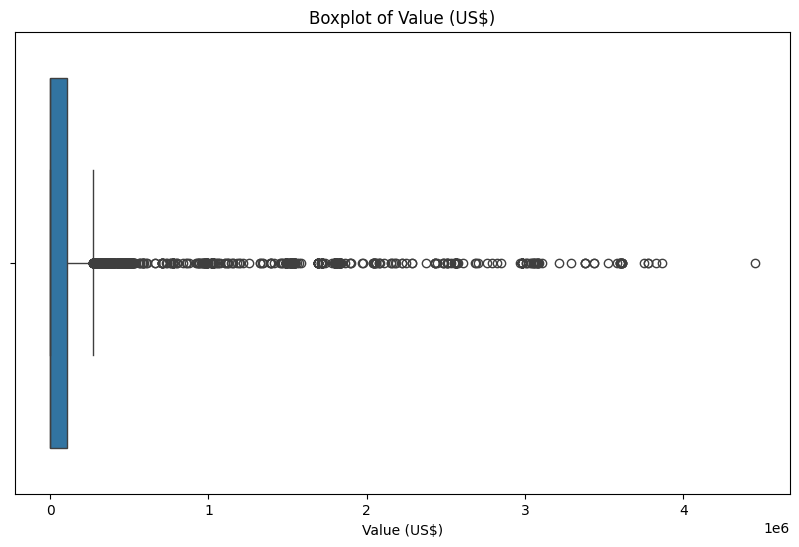

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_import['Value (US$)'])
plt.title('Boxplot of Value (US$)')
plt.xlabel('Value (US$)')
plt.show()